This notebook demonstrates a simple linear regression analysis using R to model salary based on years of experience. It also shows slope, the intercept, Pearson's correlation (r), and the mean squared error (MSE). 

In [1]:
dataset <- read.csv("regression_data-1.csv")
head(dataset)

,YearsExperience,Salary
,<dbl>,<dbl>
1,1.1,39343
2,1.3,46205
3,1.5,37731
4,2.0,43525
5,2.2,39891
6,2.9,56642


We are calculating the straight line salary (y) = slope(years of experience) + starting sallary (b) 
slope: change in salary with each year of additional experience 
y-intercept: predicted salary when years of experience = 0
r: correllation; the strenght/direction of  the linear relationship between salary and years of experience 
MSE: average squared difference between the actual and predicted salary 


In [2]:
model <- lm(Salary ~ YearsExperience, data = dataset)
slope <- coef(model)[2]
intercept <- coef(model)[1]
r <- cor(dataset$YearsExperience, dataset$Salary)
pred <- predict(model)
mse <- mean((dataset$Salary - pred)^2)

cat("Slope:", slope, "\n")
cat("Intercept:", intercept, "\n")
cat("Correlation coefficient (r):", r, "\n")
cat("Mean Squared Error (MSE):", mse, "\n")

Slope: 8285.292 
Intercept: 29203.52 
Correlation coefficient (r): 0.8860878 
Mean Squared Error (MSE): 17523844 


Interpretation: 
slope: for each additiona year of experience, the salary increases by about 8285.29. 
y-intercept: the model predicts a starting salary off 29,203.52 (0 years of experience). 
r: about 0.89 indicates strong, positive linear relationship (both are increasing). 
MSE: the square root, 4200, means the predicted values are a few thousand dollars off from the actual salary. 

`geom_smooth()` using formula = 'y ~ x'


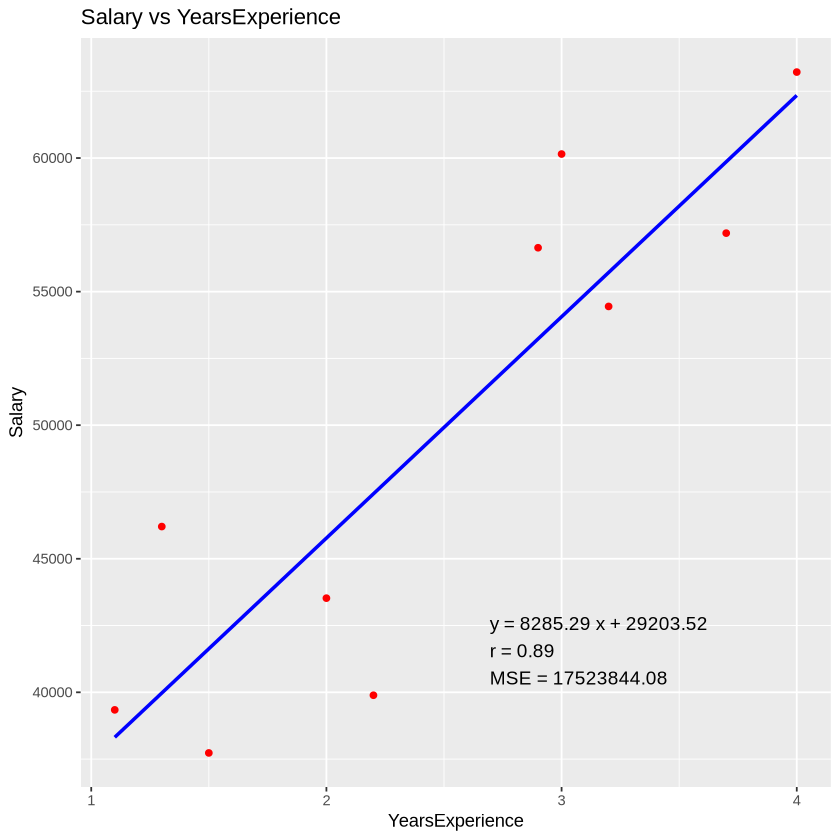

In [3]:
library(ggplot2)

label_text <- paste(
  "y =", round(slope, 2), "x +", round(intercept, 2),
  "\nr =", round(r, 2), "\nMSE =", round(mse, 2)
)

x_pos <- min(dataset$YearsExperience) +
  (max(dataset$YearsExperience) - min(dataset$YearsExperience)) * 0.55
y_pos <- min(dataset$Salary) +
  (max(dataset$Salary) - min(dataset$Salary)) * 0.15

ggplot(dataset, aes(x = YearsExperience, y = Salary)) +
  geom_point(color = "red") +
  geom_smooth(method = "lm", se = FALSE, color = "blue") +
  annotate("text", x = x_pos, y = y_pos, label = label_text, hjust = 0, size = 4) +
  ggtitle("Salary vs YearsExperience") +
  xlab("YearsExperience") +
  ylab("Salary")